Checking language type distribution in existing pretraining corpora

In [1]:
import os
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from huggingface_hub import HfApi, hf_hub_download

tqdm.pandas()

FONT_SIZES = {"small": 14, "medium": 18, "large": 24}

PLOT_PARAMS = {
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": FONT_SIZES.get("medium"),
    "axes.titlesize": FONT_SIZES.get("large"),
    "axes.labelsize": FONT_SIZES.get("large"),
    "xtick.labelsize": FONT_SIZES.get("large"),
    "ytick.labelsize": FONT_SIZES.get("large"),
    "legend.fontsize": FONT_SIZES.get("medium"),
    "figure.titlesize": FONT_SIZES.get("medium"),
    "text.usetex": True,
}

plt.rcParams.update(PLOT_PARAMS)

/Users/ljvmiranda/Developer/scratch/2026-03-20-madlad/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_madlad(lang: str, split: str = "clean_docs") -> pd.DataFrame:
    """Load MADLAD-400 data for a given language code into a DataFrame.

    Args:
        lang: Language code (e.g. 'ceb', 'tgl', 'en').
        split: Which split to load — 'clean_docs', 'noisy_docs', or 'all'.
    """
    api = HfApi()
    files = api.list_repo_tree(
        "allenai/MADLAD-400",
        path_in_repo=f"data-v1p5/{lang}",
        repo_type="dataset",
    )

    local_dir = f"data/{lang}"
    os.makedirs(local_dir, exist_ok=True)

    paths = []
    for f in files:
        if not f.rfilename.endswith(".jsonl.gz"):
            continue
        if split != "all" and split not in f.rfilename:
            continue
        path = hf_hub_download(
            "allenai/MADLAD-400",
            filename=f.rfilename,
            repo_type="dataset",
            local_dir=local_dir,
        )
        paths.append(path)

    print(f"Downloaded {len(paths)} files for '{lang}'")
    return pd.concat([pd.read_json(p, lines=True) for p in paths], ignore_index=True)

In [3]:
df = load_madlad("ceb", split="clean_docs")
df.head(5)

Downloaded 10 files for 'ceb'


,text,timestamp,url
0,Ang Brand Africa nga nagpadayon sa pagsugat sa...,2021-09-24 00:24:28+00:00,https://ceb.eturbonews.com/165852/brand-africa...
1,"Gipalihok pinaagi sa Hiyas sa pagtugnaw, pagla...",2022-05-22 18:13:01+00:00,https://cleverplus.news/news/1409-ya_no_vayas_...
2,Ang Apple adunay labing kapuslan nga mga tinda...,2021-09-26 04:32:23+00:00,https://www.soydemac.com/ceb/apple-ang-labing-...
3,Hotels.com helps you to find the best hotel fo...,2021-11-27 03:08:03+00:00,https://sg.hotels.com/de700471/ugento-italy-ho...
4,Purohan batok COVID-19 | Banat\nPurohan batok ...,2020-11-28 12:00:41+00:00,https://www.philstar.com/banat/opinyon/2020/06...


Before we do some fun stuff, might be nice to just learn more about the data

In [4]:
enc = tiktoken.get_encoding("cl100k_base")
df["token_length"] = df["text"].progress_apply(lambda x: len(enc.encode(x)))

100%|██████████| 66164/66164 [00:22<00:00, 2881.34it/s]


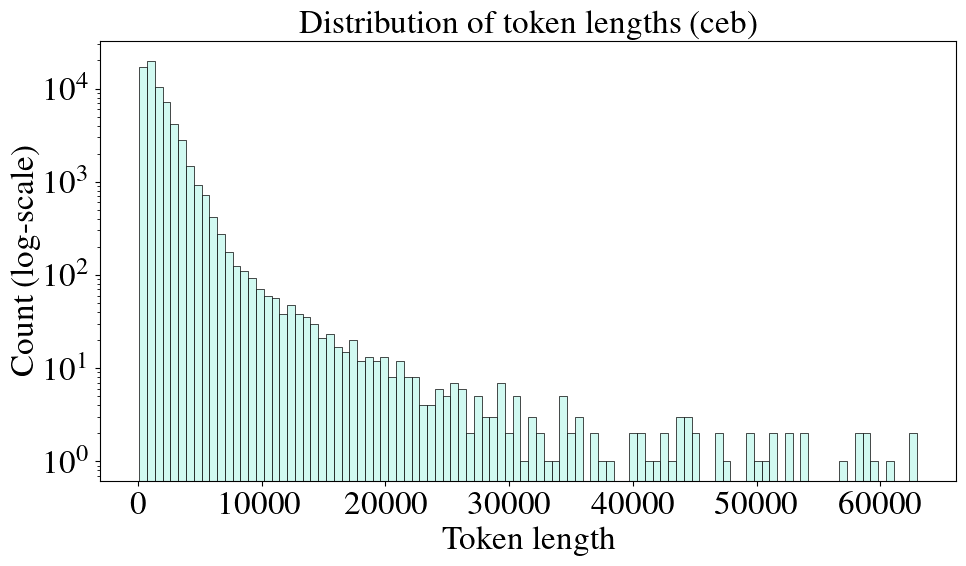

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["token_length"], bins=100, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.set_yscale("log")
ax.set_xlabel("Token length")
ax.set_ylabel("Count (log-scale)")
ax.set_title("Distribution of token lengths (ceb)")
fig.tight_layout()
plt.show()

Ideally, I'd check each text and confirm which data type they have. But assuming I don't have any knowledge about the language, what can I do? Maybe...

- Check the URLs? Perhaps there's a way to cross-reference URLs to a certain domain.
- Use an LLM? Maybe something like [this work](https://arxiv.org/pdf/2502.10341). But how do you validate this?

Let's start by checking the URLs

In [6]:
from urllib.parse import urlparse

df["tld"] = df["url"].apply(lambda x: "." + urlparse(x).netloc.rsplit(".", 1)[-1])

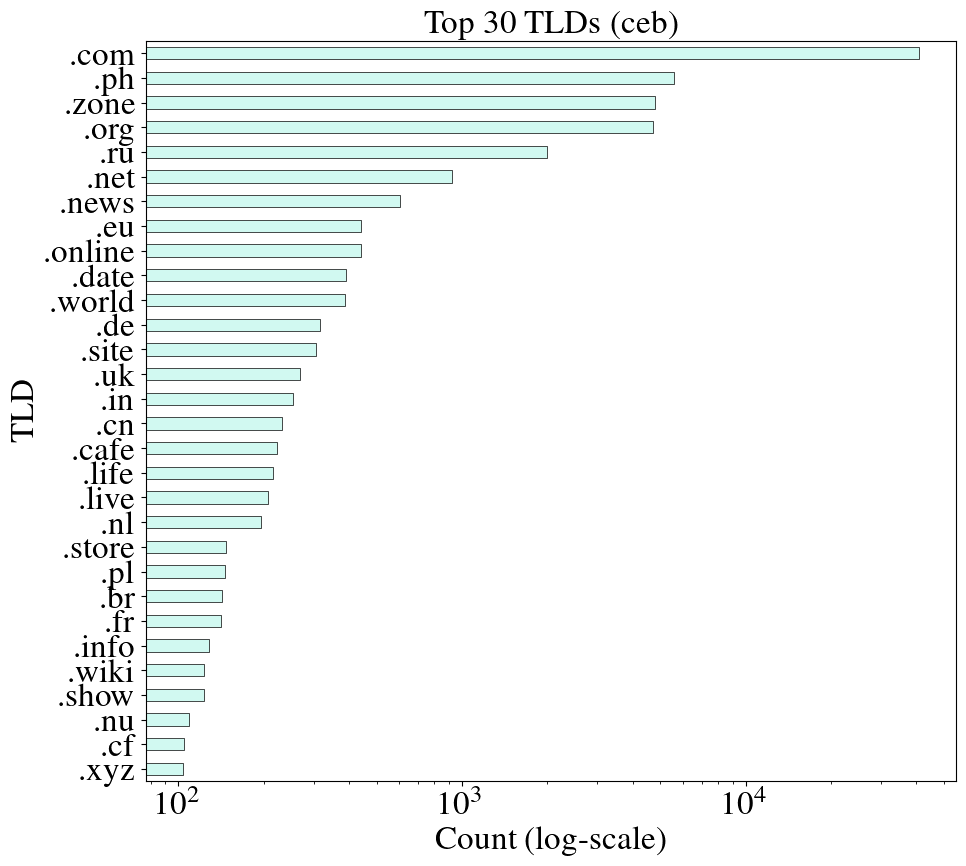

In [7]:
top_n = 30
tld_counts = df["tld"].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(10, 9))
tld_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Count (log-scale)")
ax.set_ylabel("TLD")
ax.set_title(f"Top {top_n} TLDs (ceb)")
fig.tight_layout()
plt.show()

### Topic classification

Using [WebOrganizer/TopicClassifier](https://huggingface.co/WebOrganizer/TopicClassifier) to classify documents into 24 topic categories.

In [13]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

TOPIC_LABELS = {
    0: "Adult",
    1: "Art & Design",
    2: "Software Dev.",
    3: "Crime & Law",
    4: "Education & Jobs",
    5: "Hardware",
    6: "Entertainment",
    7: "Social Life",
    8: "Fashion & Beauty",
    9: "Finance & Business",
    10: "Food & Dining",
    11: "Games",
    12: "Health",
    13: "History",
    14: "Home & Hobbies",
    15: "Industrial",
    16: "Literature",
    17: "Politics",
    18: "Religion",
    19: "Science & Tech.",
    20: "Software",
    21: "Sports & Fitness",
    22: "Transportation",
    23: "Travel",
}

device = torch.device("cpu")

topic_tokenizer = AutoTokenizer.from_pretrained("WebOrganizer/TopicClassifier")
topic_model = (
    AutoModelForSequenceClassification.from_pretrained(
        "WebOrganizer/TopicClassifier",
        trust_remote_code=True,
        use_memory_efficient_attention=False,
        torch_dtype=torch.float32,
    )
    .to(device)
    .eval()
)

Loading weights: 100%|██████████| 139/139 [00:00<00:00, 16686.94it/s]


In [16]:
@torch.no_grad()
def classify_topic(text: str, url: str = "") -> str:
    """Classify a single document into one of 24 topic categories."""
    input_text = f"{url}\n\n{text}" if url else text
    inputs = topic_tokenizer([input_text], return_tensors="pt", truncation=True).to(
        device
    )
    seq_len = inputs["input_ids"].shape[1]
    inputs["position_ids"] = torch.arange(
        seq_len, dtype=torch.long, device=device
    ).unsqueeze(0)
    outputs = topic_model(**inputs)
    pred = outputs.logits.softmax(dim=-1).argmax(dim=-1).item()
    return TOPIC_LABELS[pred]


# Quick test
print("{url}\nn{text}".format(url=df["url"].iloc[0], text=df["text"].iloc[0]))
classify_topic(df["text"].iloc[0], df["url"].iloc[0])

https://ceb.eturbonews.com/165852/brand-africa-nga-nagpadayon-sa-unahan-sa-zambia-nagtagbo-sa-mga-asosasyon-sa-pagdumala-sa-pantalan/
nAng Brand Africa nga nagpadayon sa pagsugat sa Zambia sa Ports Management Association\nHome » Pinakabag-ong Mga Artikulo sa Balita » Mga Kasayuran nga Balita » Ang Brand Africa nga nagpadayon sa pagsugat sa Zambia sa Ports Management Association\nMga Kasayuran nga Balita • Pagbungkag sa Balita sa Pagbiyahe • Pag-cruis • Balita • Turismo • Transportation • Pagbag-o sa Destinasyon sa Pagbiyahe • Balita sa Travel Wire • Balita sa Pagbungkag sa Zambia\nAng Ministro sa Turismo ug Sining nga si Hon. Gisulti ni Charles Banda nga ang Zambia sa dili madugay makita kung unsa ang labing kaayo aron mapalambo ang turismo sa cruise pinaagi sa paggamit sa mga magamit nga mga tubig nga tubig ingon ang Seychelles 'Head of Mission sa Zambia, si Jamil (Jimmy) Butt, nagsulti nga ang iyang nasud gusto nga magtubo ang usa ka bilateral nga panaghigalaay sa linya sa Kasabutan 

'Adult'

In [20]:
df_sample = df.sample(100)
df_sample["topic"] = df_sample.progress_apply(
    lambda row: classify_topic(row["text"], row["url"]), axis=1
)

100%|██████████| 100/100 [00:41<00:00,  2.43it/s]


In [35]:
def inspect_topic(df: pd.DataFrame, topic: str, n: int = 5) -> pd.DataFrame:
    """Sample n rows from a given topic and display text snippets."""
    subset = df[df["topic"] == topic]
    sample = subset.sample(min(n, len(subset)))
    for _, row in sample.iterrows():
        print(f"[{row['topic']}] {row['url']}")
        print(row["text"][:300])
        print("---")
    return sample


inspect_topic(df_sample, "Science & Tech.", n=5)

[Science & Tech.] https://www.bescatray.com/ceb/solutions/solar-engineering-2/
Gahum nga gihatag sa adlaw. Performance nga gihatag sa Cooper B-Line.\nBesca mga laraw ug manupaktura sa industriya-unang solar yugto ug nagkadakong mga solusyon alang sa Commercial ug Utility Scale photovoltaic mga proyekto.? Installers ug mga tag-iya sa proyekto mianhi sa pagsalig sa atong solar y
---
[Science & Tech.] https://www.meteorologiaenred.com/ceb/alfred-wegener.html
Kinsa si Alfred Wegener? Biyograpiya ug kasaysayan | Meteorolohiya sa Network\nKinsa si Alfred Wegener?\nSa high school nahibal-an nimo nga ang mga kontinente wala magbarug nga hilum alang sa tibuuk nga kasaysayan sa Yuta. Sa sukwahi, padayon sila nga naglihok. Alfred Wegener ang siyentista nga nagp
---
[Science & Tech.] https://rmn.ph/weather-update-bagyong-ramon-posibling-mo-landfall-sa-babuyan-islands-karong-adlawa-2/
Nov. 19, 2019 at 12:44pm\n11:50 AM 19NOV2019\nGipahibalo sa City Disaster Risk Reduction and Management Department 

,text,timestamp,url,token_length,tld,topic
19752,Gahum nga gihatag sa adlaw. Performance nga gi...,2020-04-05 00:08:24+00:00,https://www.bescatray.com/ceb/solutions/solar-...,373,.com,Science & Tech.
42579,Kinsa si Alfred Wegener? Biyograpiya ug kasays...,2021-12-01 19:27:32+00:00,https://www.meteorologiaenred.com/ceb/alfred-w...,2692,.com,Science & Tech.
27302,"Nov. 19, 2019 at 12:44pm\n11:50 AM 19NOV2019\n...",2020-07-13 07:37:15+00:00,https://rmn.ph/weather-update-bagyong-ramon-po...,483,.ph,Science & Tech.
28147,Unsa ang mga gemstones nga mga phenomena sa ma...,2021-09-17 00:14:01+00:00,https://ceb.gem.agency/Ang-mga-gemstones-sa-mg...,1435,.agency,Science & Tech.
36235,Nagtukod ang mga siyentipiko og artipisyal nga...,2019-10-15 21:36:04+00:00,https://ceb.teles-relay.com/2019/09/10/nagtuko...,893,.com,Science & Tech.


<>:9: SyntaxWarning: invalid escape sequence '\#'
<>:9: SyntaxWarning: invalid escape sequence '\#'
/var/folders/sr/yrkfz9x97657016n6k2bm8280000gn/T/ipykernel_21854/1629300319.py:9: SyntaxWarning: invalid escape sequence '\#'
  ax.set_title(f"Topic distribution (ceb), \# of samples = {len(df_sample)}")


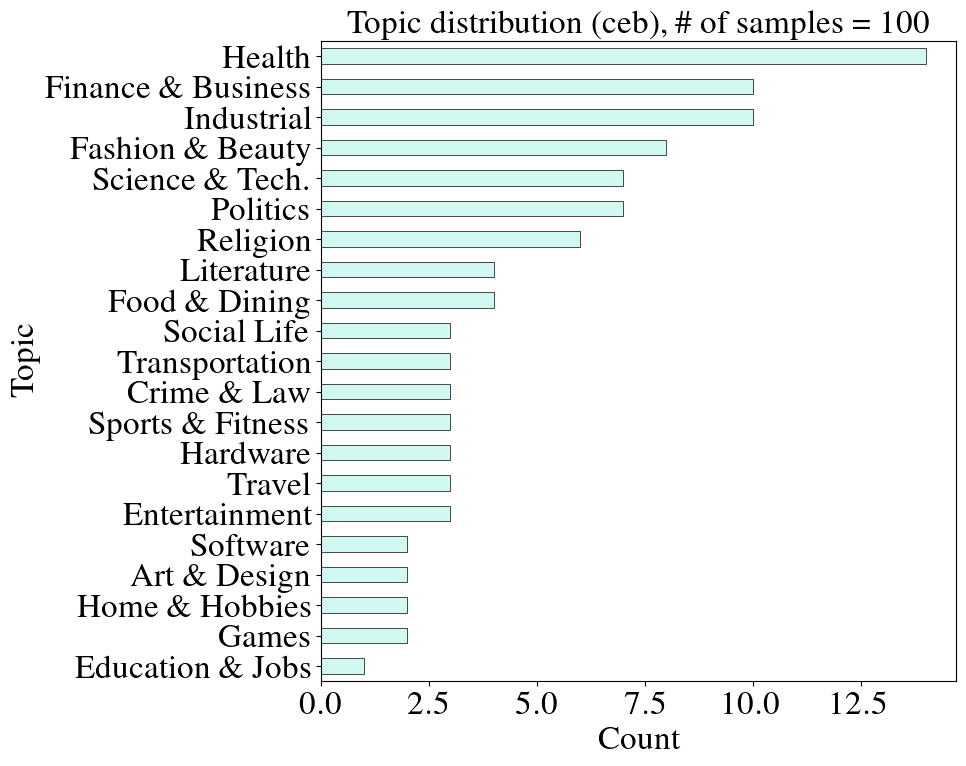

In [33]:
topic_counts = df_sample["topic"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
topic_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_yticklabels([label.replace("&", r"\&") for label in topic_counts.index])
ax.set_xlabel("Count")
ax.set_ylabel("Topic")
ax.set_title(f"Topic distribution (ceb), \# of samples = {len(df_sample)}")
fig.tight_layout()
plt.show()

### Format classification

Using [WebOrganizer/FormatClassifier](https://huggingface.co/WebOrganizer/FormatClassifier) to classify documents into 24 format categories.

In [ ]:
FORMAT_LABELS = {
    0: "Academic Writing",
    1: "Content Listing",
    2: "Creative Writing",
    3: "Customer Support",
    4: "Comment Section",
    5: "FAQ",
    6: "Truncated",
    7: "Knowledge Article",
    8: "Legal Notices",
    9: "Listicle",
    10: "News Article",
    11: "Nonfiction Writing",
    12: "About (Org.)",
    13: "News (Org.)",
    14: "About (Pers.)",
    15: "Personal Blog",
    16: "Product Page",
    17: "Q&A Forum",
    18: "Spam / Ads",
    19: "Structured Data",
    20: "Documentation",
    21: "Audio Transcript",
    22: "Tutorial",
    23: "User Review",
}

format_tokenizer = AutoTokenizer.from_pretrained("WebOrganizer/FormatClassifier")
format_model = (
    AutoModelForSequenceClassification.from_pretrained(
        "WebOrganizer/FormatClassifier",
        trust_remote_code=True,
        use_memory_efficient_attention=False,
        torch_dtype=torch.float32,
    )
    .to(device)
    .eval()
)

In [ ]:
@torch.no_grad()
def classify_format(text: str, url: str = "") -> str:
    """Classify a single document into one of 24 format categories."""
    input_text = f"{url}\n\n{text}" if url else text
    inputs = format_tokenizer([input_text], return_tensors="pt", truncation=True).to(
        device
    )
    seq_len = inputs["input_ids"].shape[1]
    inputs["position_ids"] = torch.arange(
        seq_len, dtype=torch.long, device=device
    ).unsqueeze(0)
    outputs = format_model(**inputs)
    pred = outputs.logits.softmax(dim=-1).argmax(dim=-1).item()
    return FORMAT_LABELS[pred]


# Quick test
classify_format(df["text"].iloc[0], df["url"].iloc[0])

In [ ]:
df_sample["format"] = df_sample.progress_apply(
    lambda row: classify_format(row["text"], row["url"]), axis=1
)

In [ ]:
format_counts = df_sample["format"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
format_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_yticklabels([label.replace("&", r"\&") for label in format_counts.index])
ax.set_xlabel("Count")
ax.set_ylabel("Format")
ax.set_title("Format distribution (ceb)")
fig.tight_layout()
plt.show()

In [ ]:
def inspect_format(df: pd.DataFrame, fmt: str, n: int = 5) -> pd.DataFrame:
    """Sample n rows from a given format and display text snippets."""
    subset = df[df["format"] == fmt]
    sample = subset.sample(min(n, len(subset)))
    for _, row in sample.iterrows():
        print(f"[{row['format']}] {row['url']}")
        print(row["text"][:300])
        print("---")
    return sample


inspect_format(df_sample, "News Article", n=3)